In [42]:
# To import a real-world dataset from a public repository and perform data cleaning
# techniques such as handling missing values and normalization.
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler



# Titanic dataset directly from Seaborn's public repository
df = sns.load_dataset('titanic')

print("Initial Dataset Shape:", df.shape)
print("\nMissing values before cleaning:")
print(df.isnull().sum())

#  Fill missing value of age with the median
df['age'] = df['age'].fillna(df['age'].median())

#  Fill missing categorical values (embarked) with the mode (most common value)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

#  Drop columns with more missing data (deck morethen 70% missing values)
df = df.drop(columns=['deck', 'embark_town'])

# Drop remaining rows with missing values (if any)
df = df.dropna()

print("\nMissing values after cleaning:")
print(df.isnull().sum())


# Convert binary categorical values to numerical indicators (0/1) 
df['sex'] = df['sex'].map({'female': 1, 'male': 0})

# One-Hot Encode non-ordinal categorical variables
df = pd.get_dummies(df, columns=['embarked'], drop_first=True, dtype=int)

#  Min-Max Normalization (Scales values between 0 and 1)
min_max_scaler = MinMaxScaler()
df['fare_normalized'] = min_max_scaler.fit_transform(df[['fare']])

# Normalize age
scaler = MinMaxScaler()
df['age_normalized'] = scaler.fit_transform(df[['age']])

df.to_csv("clean_titanic.csv", index=False)

print("\nFinal Dataset Preview:")
print(df[['survived', 'pclass', 'sex', 'age_normalized', 'fare_normalized']].head())

Initial Dataset Shape: (891, 15)

Missing values before cleaning:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Missing values after cleaning:
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

Final Dataset Preview:
   survived  pclass  sex  age_normalized  fare_normalized
0         0       3    0        0.271174         0.014151
1         1       1    1        0.472229         0.139136
2         1       3    1        0.321438         0.015469
3         1       1    1        0.434531         0.103644
4         0       3    0        0.434531         0.015713


actual value
predected value 
accuracy is : 0.5921787709497207


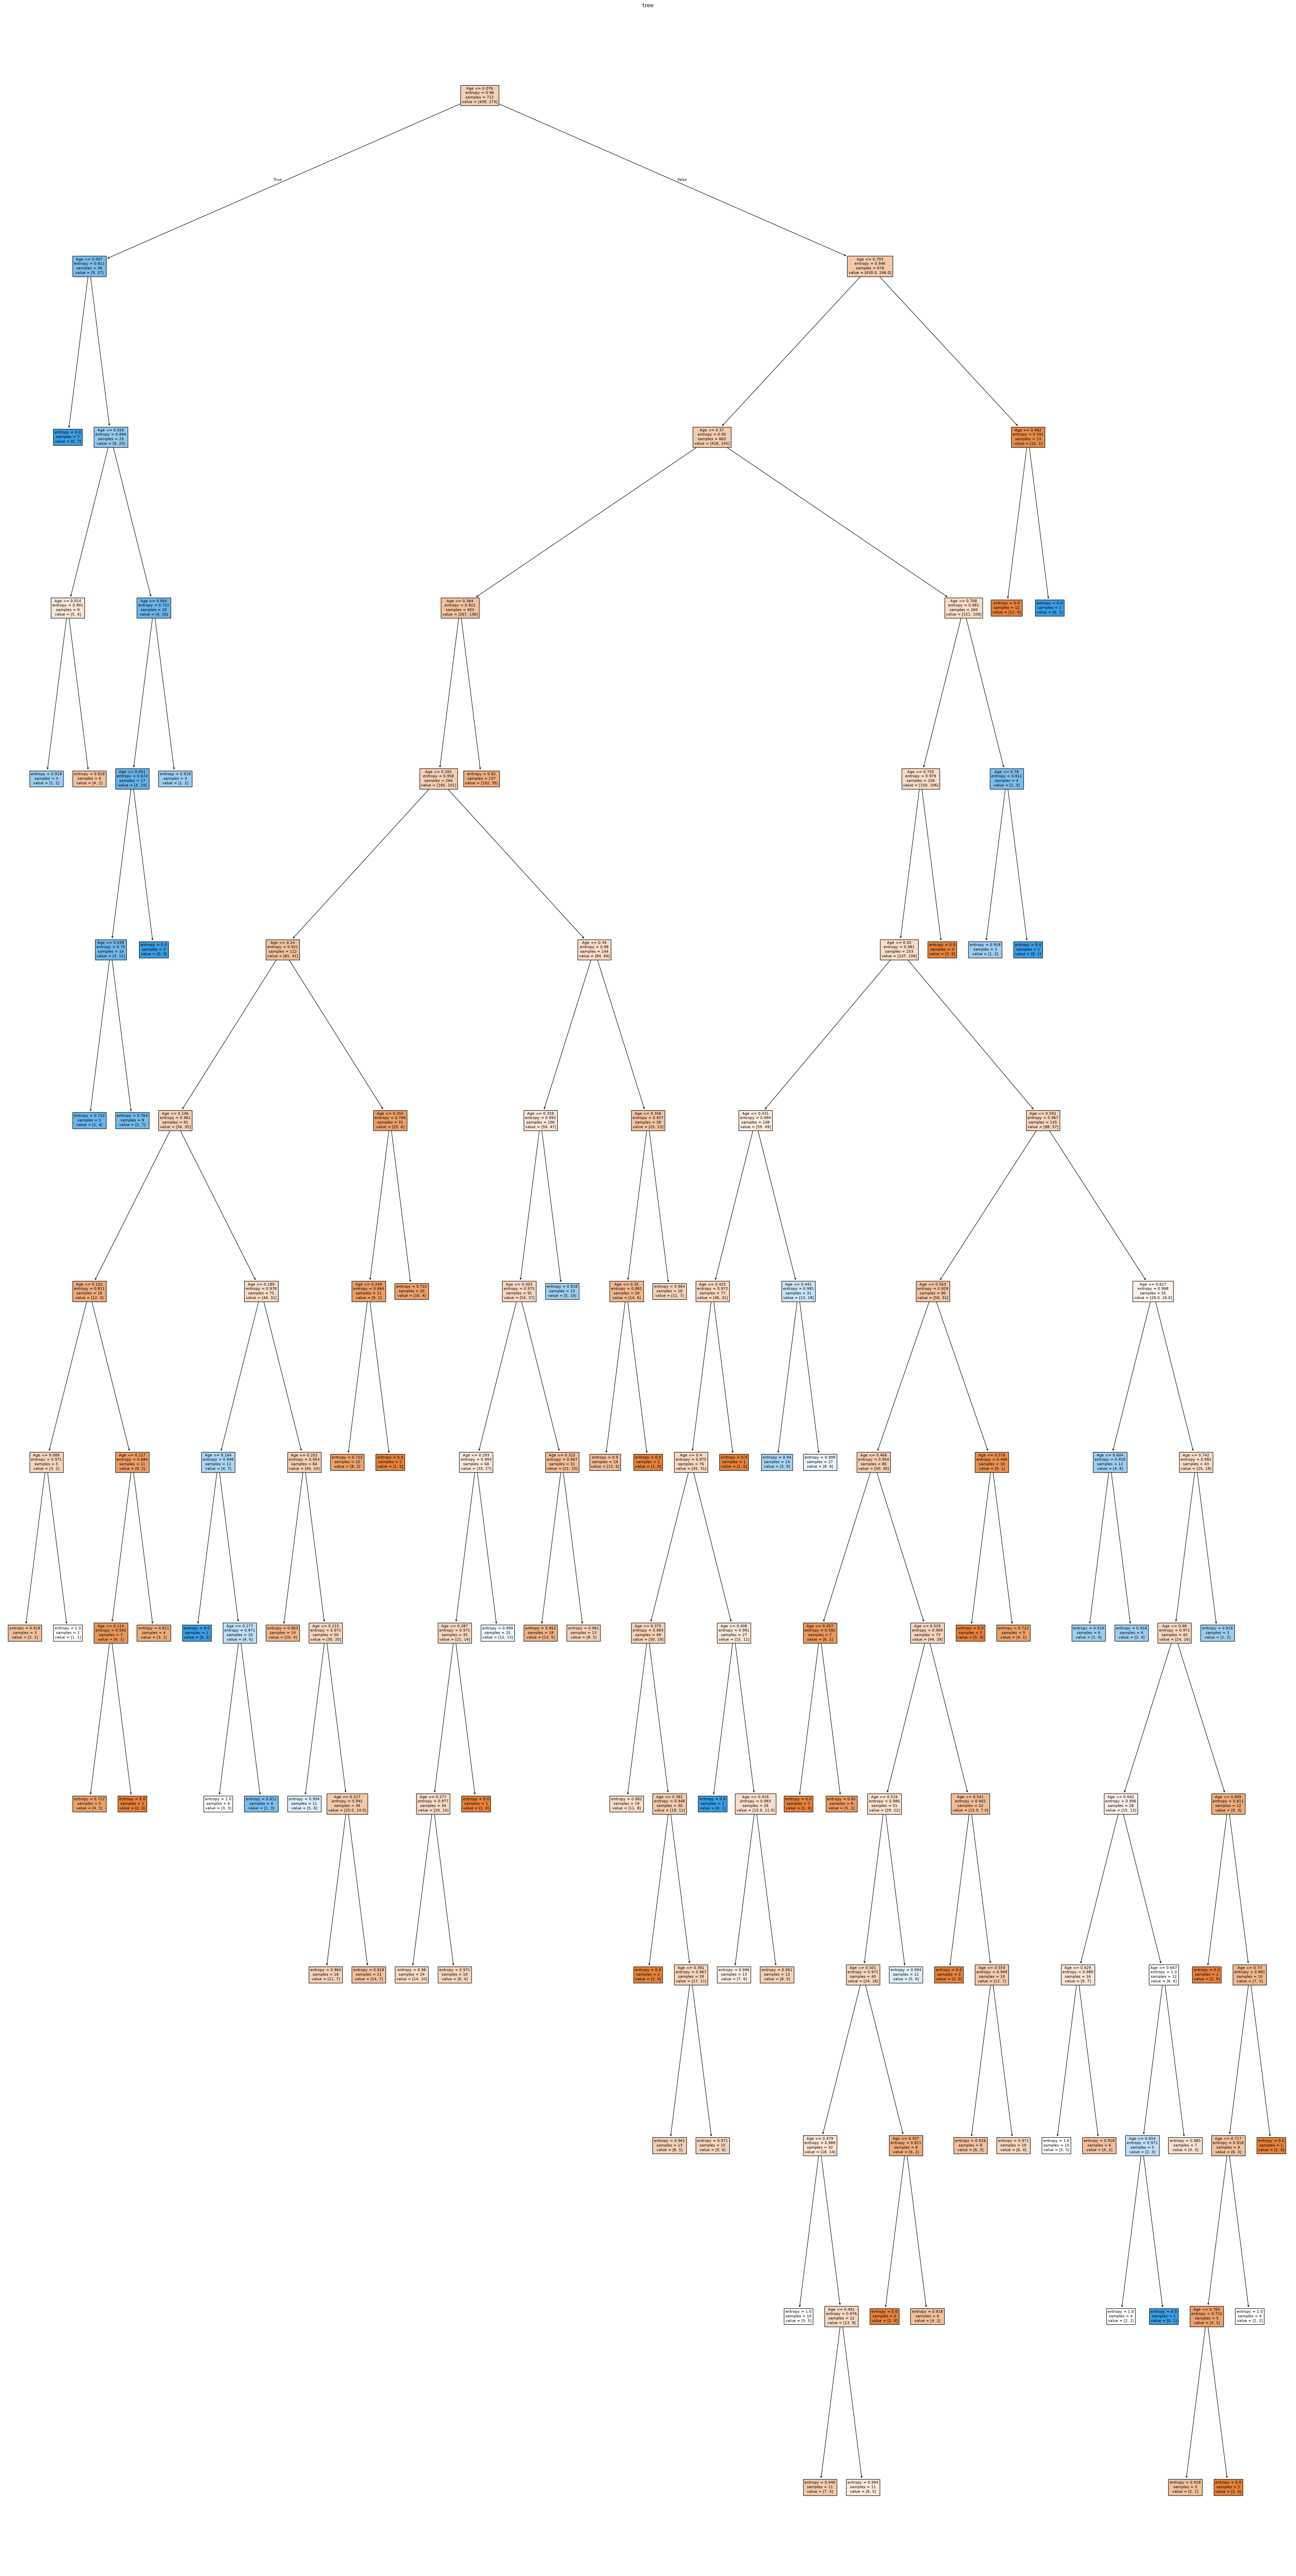

,PassengerId,Survived,Name,Sex,Age
0,1,0,"Braund, Mr. Owen Harris",male,0.271174
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.472229
2,3,1,"Heikkinen, Miss. Laina",female,0.321438
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.434531
4,5,0,"Allen, Mr. William Henry",male,0.434531


In [33]:
# Decision tree for Taitenic dataset by age 

import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

data = pd.read_csv(r"C:\Users\Solanki Ronak\OneDrive\Desktop\code\Git\datascience\clean_titanic.csv")
# data
data.drop(columns=["Ticket","Fare","Embarked","SibSp","Parch","Pclass"],inplace=True)

le = LabelEncoder()

# data["Sex"] = le.fit_transform(data["Sex"])

input_x = data[["Age"]]
result_y= data[["Survived"]]

input_x_train,input_x_test,result_y_train,result_y_test=train_test_split(input_x,result_y,test_size=0.2,random_state=43)

model = DecisionTreeClassifier(criterion="entropy",random_state=43)
model.fit(input_x_train,result_y_train)

y_pred = model.predict(input_x_test)
print("actual value")
# print(result_y_test.values)
print("predected value ")
# print(y_pred)

accuracy = accuracy_score(result_y_test,y_pred)
print("accuracy is :",accuracy)

plt.figure(figsize=(50,100))
plot_tree(model,feature_names=["Age"],filled=True)
plt.title("tree")
plt.show()

data.head()